In [27]:
import numpy as np
import matplotlib.pyplot as plt
from autogluon.tabular import TabularPredictor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample


In [28]:
df = pd.read_csv("/home/server/Projects/data/AKI/preop_data_andrew.csv")
df["aki_boolean"] = (df["aki"] > 0.3).astype(int)
to_pop = [  "aki", "postop_creatinine", "Unnamed: 0", "op_id", "subject_id", 
            "opstart_time", "opend_time", "inhosp_death_time", "allcause_death_time"
          ]
for col in to_pop:
    df.pop(col)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# fitting/training model
label = 'aki_boolean'
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["aki_boolean"])

df_majority = df_train[df_train["aki_boolean"] == 0]
df_minority = df_train[df_train["aki_boolean"] == 1]

df_minority_upsampled = resample(df_minority,
                                 replace=True,  # Sample with replacement
                                 n_samples=len(df_majority),  # Match majority class size
                                 random_state=42)
df_upsampled = pd.concat([df_majority, df_minority_upsampled]).sample(frac=1)



In [33]:
predictor = TabularPredictor(label=label).fit(df_upsampled)

No path specified. Models will be saved in: "AutogluonModels/ag-20250221_044955"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #141-Ubuntu SMP Fri Jan 10 21:18:28 UTC 2025
CPU Count:          8
Memory Avail:       25.04 GB / 29.31 GB (85.4%)
Disk Space Avail:   254.03 GB / 913.32 GB (27.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions and be

[1000]	valid_set's binary_error: 0.058
[2000]	valid_set's binary_error: 0.028
[3000]	valid_set's binary_error: 0.016
[4000]	valid_set's binary_error: 0.0132
[5000]	valid_set's binary_error: 0.0112
[6000]	valid_set's binary_error: 0.0108
[7000]	valid_set's binary_error: 0.0096
[8000]	valid_set's binary_error: 0.0084
[9000]	valid_set's binary_error: 0.008
[10000]	valid_set's binary_error: 0.0072


	0.9932	 = Validation score   (accuracy)
	31.48s	 = Training   runtime
	0.54s	 = Validation runtime
Fitting model: LightGBM ...


[1000]	valid_set's binary_error: 0.0368
[2000]	valid_set's binary_error: 0.0132
[3000]	valid_set's binary_error: 0.0092
[4000]	valid_set's binary_error: 0.0068
[5000]	valid_set's binary_error: 0.0068


	0.9932	 = Validation score   (accuracy)
	18.1s	 = Training   runtime
	0.22s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9936	 = Validation score   (accuracy)
	13.39s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9944	 = Validation score   (accuracy)
	12.72s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: CatBoost ...
	0.9888	 = Validation score   (accuracy)
	249.07s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.9968	 = Validation score   (accuracy)
	8.72s	 = Training   runtime
	0.08s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.9968	 = Validation score   (accuracy)
	8.67s	 = Training   runtime
	0.08s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	0.9748	 = Validation score   (accuracy)
	82.94s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: XGBoost ...
	0.9884	 = Validation score   (accuracy)
	11.76s	 = Training   runtime
	

[1000]	valid_set's binary_error: 0.0108
[2000]	valid_set's binary_error: 0.0076


	0.994	 = Validation score   (accuracy)
	22.05s	 = Training   runtime
	0.24s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Ensemble Weights: {'ExtraTreesGini': 0.857, 'KNeighborsDist': 0.143}
	0.9976	 = Validation score   (accuracy)
	0.16s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 1210.58s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 5363.8 rows/s (2500 batch size)
Disabling decision threshold calibration for metric `accuracy` due to having fewer than 10000 rows of validation data for calibration, to avoid overfitting (2500 rows).
	`accuracy` is generally not improved through threshold calibration. Force calibration via specifying `calibrate_decision_threshold=True`.
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/server/Projects/VitalDB-Dimensionality-Reduction/preoperative_models/aki_experiments/AutogluonModels/ag-20250221_044955")


In [38]:
predictor = TabularPredictor.load("AutogluonModels/ag-20250221_044955") #upsampled to 50/50
X_test = df_test.drop(columns=[label])
y_test = df_test[label]
y_pred = predictor.predict(X_test)
y_prob = predictor.predict_proba(X_test)[1]

In [40]:
dir(predictor)

['Dataset',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_assert_is_fit',
 '_can_calibrate_decision_threshold',
 '_check_if_hyperparameters_handle_text',
 '_decision_threshold',
 '_dynamic_stacking',
 '_fit',
 '_fit_extra_kwargs_dict',
 '_fit_strategy',
 '_fit_weighted_ensemble_pseudo',
 '_get_all_fit_extra_args',
 '_get_dataset',
 '_initialize_learning_curve_params',
 '_learner',
 '_learner_type',
 '_load',
 '_load_metadata_file',
 '_load_version_file',
 '_model_best',
 '_post_fit',
 '_predict_pseudo',
 '_predictor_log_file_name',
 '_predictor_metadata_file_name',
 '_predictor_version_file_name',
 '_prune_data_features',
 '_run_pseudolabeling',
 

Accuracy: 0.94
Confusion Matrix:
[[10971    68]
 [  618    81]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     11039
           1       0.54      0.12      0.19       699

    accuracy                           0.94     11738
   macro avg       0.75      0.55      0.58     11738
weighted avg       0.92      0.94      0.92     11738



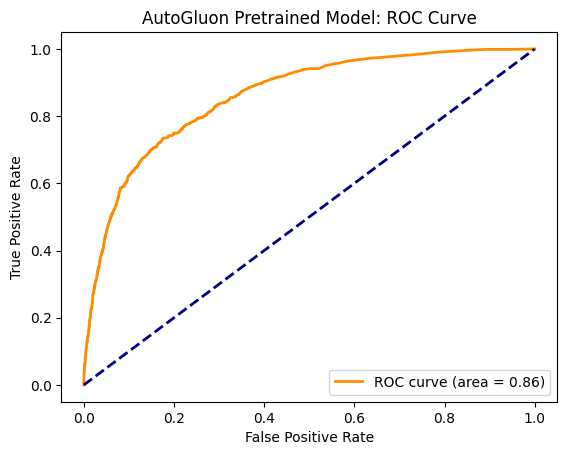

In [39]:
# -------------------- Evaluate Model Performance --------------------
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_test, y_pred)
print('Classification Report:')
print(report)

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AutoGluon Pretrained Model: ROC Curve')
plt.legend(loc='lower right')
plt.show()

Accuracy: 1.00
Confusion Matrix:
[[44152     6]
 [    0 44158]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44158
           1       1.00      1.00      1.00     44158

    accuracy                           1.00     88316
   macro avg       1.00      1.00      1.00     88316
weighted avg       1.00      1.00      1.00     88316



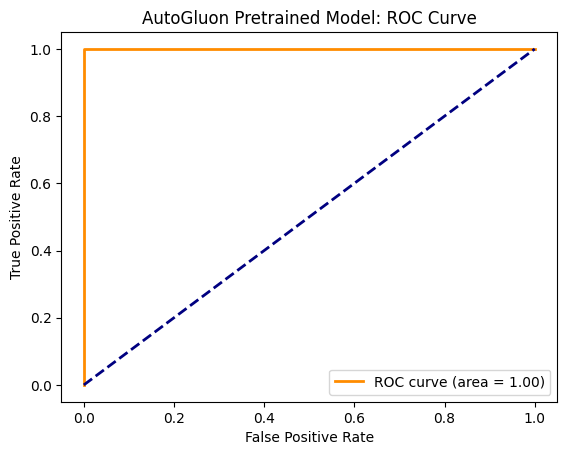

In [ ]:
# Load test data
with np.load('/home/server/Projects/data/AKI/preop_trainable/unfiltered.npz', allow_pickle=True) as data:
    X_test = data["X_test"]
    y_binary_test = data["y_binary_test"]

In [3]:
# Convert test data to Pandas DataFrame (AutoGluon expects a DataFrame)
test_df = pd.DataFrame(X_test)

In [ ]:
predictor = TabularPredictor.load("../../AutogluonModels/ag-20250209_075326")  # Change path to your saved model

In [ ]:
# Predict binary labels
y_pred = predictor.predict(test_df)

# Predict probabilities (Fix for KeyError)
y_prob_df = predictor.predict_proba(test_df)
y_prob = y_prob_df.iloc[:, 1]  # Get probability for class 1


In [ ]:
# -------------------- Evaluate Model Performance --------------------
accuracy = accuracy_score(y_binary_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred)
print('Classification Report:')
print(report)

Accuracy: 0.94
Confusion Matrix:
[[9596    0]
 [ 659    0]]
Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97      9596
        True       0.00      0.00      0.00       659

    accuracy                           0.94     10255
   macro avg       0.47      0.50      0.48     10255
weighted avg       0.88      0.94      0.90     10255



/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramete

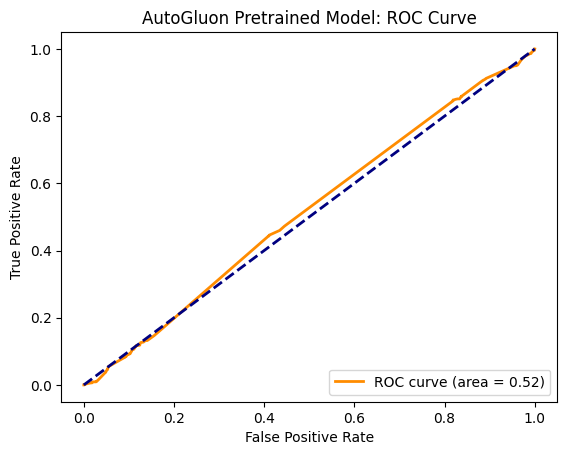

In [ ]:
# Compute ROC curve
fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AutoGluon Pretrained Model: ROC Curve')
plt.legend(loc='lower right')
plt.show()